# Lab Report for Antenna of Group 1 (Wörner, Velez, Northe)

The source code and the binaries from this report can be found in our Github [repository](https://github.com/NortheLo/Microwave_Eng_Lab/tree/main/Lab5_Antennas).

In [23]:
from scipy.io import loadmat
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

def loadMatlabData(path):
    """
    Loads a .mat file from the given path and returns a cleaned dictionary.

    Parameters:
        path (str): Relative or absolute path to the .mat file.

    Returns:
        dict: A dictionary containing variable names and their corresponding NumPy arrays.
    """
    raw = loadmat(path)

    # Remove MATLAB metadata keys
    cleaned = {k: v for k, v in raw.items() if not k.startswith('__')}

    # Flatten 1D arrays and ensure consistent data types
    for key, value in cleaned.items():
        if isinstance(value, np.ndarray) and value.ndim == 2 and 1 in value.shape:
            cleaned[key] = value.flatten()
        else:
            cleaned[key] = np.array(value)

    return cleaned


def plot_polarizations(co_path, cross_path, title="Measured Radiation Pattern", prominence=5):
    """
    Plots co- and cross-polarization radiation patterns from two .mat files.
    Automatically computes and marks HPBW and nulls in the co-polarization curve.
    Also calculates cross polarization suppression (XPS) within the HPBW.

    Parameters:
        co_path (str): Path to co-polarization .mat file.
        cross_path (str): Path to cross-polarization .mat file.
        title (str): Plot title.
        prominence (float): Minimum prominence (in dB) to detect nulls.
    """
    # Load co-polarization
    co_data = loadMatlabData(co_path)
    mess_co = co_data['messdummy'][0]
    angles = mess_co['angles'].flatten()
    E_co = mess_co['measured_data'].flatten()
    E_co_dB = 20 * np.log10(np.abs(E_co)) ###

    # Load cross-polarization
    cross_data = loadMatlabData(cross_path)
    mess_cross = cross_data['messdummy'][0]
    E_cross = mess_cross['measured_data'].flatten()
    E_cross_dB = 20 * np.log10(np.abs(E_cross)) ###

    # --- Half Power Beam Width ---
    max_E = np.max(E_co_dB)
    threshold = max_E - 3
    hpbw_indices = np.where(E_co_dB >= threshold)[0]
    if len(hpbw_indices) >= 2:
        hpbw_left = angles[hpbw_indices[0]]
        hpbw_right = angles[hpbw_indices[-1]]
        hpbw_range = (hpbw_left, hpbw_right)
    else:
        hpbw_range = (None, None)

    # --- Cross-Polarization Suppression (XPS) ---
    if hpbw_range[0] is not None:
        in_hpbw = (angles >= hpbw_range[0]) & (angles <= hpbw_range[1])
        G_co = np.max(E_co_dB[in_hpbw])
        G_x = np.max(E_cross_dB[in_hpbw])
        xps = G_co - G_x
    else:
        G_co = G_x = xps = None

    # --- Nulls ---
    null_indices, _ = find_peaks(-E_co_dB, prominence=prominence)
    null_angles = angles[null_indices]
    null_values = E_co_dB[null_indices]

    # --- Plot ---
    plt.figure(figsize=(8, 5))
    plt.plot(angles, E_co_dB, label='Co-polarization')
    plt.plot(angles, E_cross_dB, label='Cross-polarization', linestyle='--')

    # Mark HPBW
    if hpbw_range[0] is not None:
        plt.axvline(hpbw_left, color='green', linestyle='--', label='-3 dB points')
        plt.axvline(hpbw_right, color='green', linestyle='--')
        plt.fill_between(angles, E_co_dB, max_E - 3,
                         where=(angles >= hpbw_left) & (angles <= hpbw_right),
                         color='lightgreen', alpha=0.3, label='HPBW region')

    # Mark Nulls
    if len(null_angles) > 0:
        plt.plot(null_angles, null_values, 'ro', label='Nulls')
        for a, v in zip(null_angles, null_values):
            plt.text(a, v - 2, f"{a:.1f}°", ha='center', fontsize=8, color='red')

    # Final plot formatting
    plt.xlabel("Angle (degrees)")
    plt.ylabel("Amplitude (dB)")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # --- Print results ---
    if hpbw_range[0] is not None:
        print(f"HPBW: {hpbw_right - hpbw_left:.2f}° (from {hpbw_left:.1f}° to {hpbw_right:.1f}°)")
    else:
        print("HPBW could not be determined.")

    print(f"Nulls found at angles (deg): {[f'{a:.1f}' for a in null_angles]}")
    
    if xps is not None:
        print(f"Cross Polarization Suppression (XPS): {xps:.2f} dB")
        print(f"  Co-pol max within HPBW: {G_co:.2f} dB")
        print(f"  Cross-pol max within HPBW: {G_x:.2f} dB")
    else:
        print("XPS could not be calculated.")

def plot_array_patterns(paths, labels=None, title="Patch Array Beam Steering", prominence=3):
    """
    Plots multiple patch array radiation patterns and marks HPBW for each.

    Parameters:
        paths (list of str): Paths to .mat files (1 per phase setting).
        labels (list of str): Optional list of labels (default: Phase Setting 1, 2, 3...).
        title (str): Title for the plot.
        prominence (float): dB threshold to define HPBW (-3 dB region).
    """
    if labels is None:
        labels = [f"Phase Setting {i+1}" for i in range(len(paths))]

    plt.figure(figsize=(8, 5))

    for i, path in enumerate(paths):
        # Load and extract data
        data = loadMatlabData(path)
        mess = data['messdummy'][0]
        angles = mess['angles'].flatten()
        E = mess['measured_data'].flatten()
        E_dB = 20 * np.log10(np.abs(E)) ###

        # Plot pattern
        plt.plot(angles, E_dB, label=labels[i])

        # HPBW: Find -3 dB boundaries
        max_E = np.max(E_dB)
        threshold = max_E - 3
        hpbw_indices = np.where(E_dB >= threshold)[0]
        if len(hpbw_indices) >= 2:
            left = angles[hpbw_indices[0]]
            right = angles[hpbw_indices[-1]]

            plt.axvline(left, linestyle='--', color='gray', alpha=0.5)
            plt.axvline(right, linestyle='--', color='gray', alpha=0.5)

            plt.fill_between(
                angles, E_dB, threshold,
                where=(angles >= left) & (angles <= right),
                color='lightgreen', alpha=0.3,
                label='HPBW region' if i == 0 else None
            )

    # Final plot formatting
    plt.xlabel("Angle (degrees)")
    plt.ylabel("Amplitude (dB)")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

### 5.6 Exercise 6 – Horn Antenna Measurements (Experiment)

- Record the radiation pattern (**Co- and Cross-polarization**) of both horn antennas in the **E-plane** and **H-plane** for **f = 11.85 GHz**.
    - Horn 1: extended in **E-plane**
    - Horn 2: extended in **H-plane**

- Print the following (**not normalized**) diagrams:
    1. Co- and X-polarization in the E-plane for horn 1 in one diagram
    2. Co- and X-polarization in the H-plane for horn 1 in one diagram
    3. Co- and X-polarization in the E-plane for horn 2 in one diagram
    4. Co- and X-polarization in the H-plane for horn 2 in one diagram

- Mark the half power beam width and the nulls in all diagrams (only Co-polarization)
- Extract the following values from the 4 diagrams:
    -  Half power beam width (Co-polarization)
    -  Cross polarization suppression


####  5.6.1 Co- and Cross-polarization in the **E-plane** for **Horn 1** in one diagram


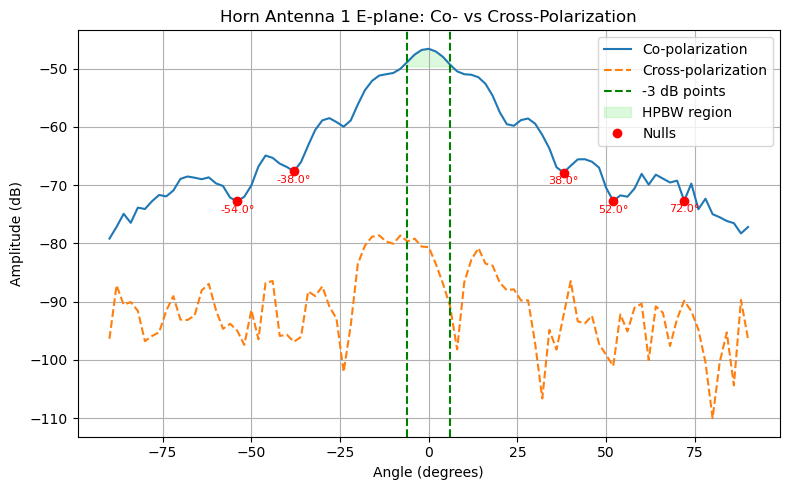

HPBW: 12.00° (from -6.0° to 6.0°)
Nulls found at angles (deg): ['-54.0', '-38.0', '38.0', '52.0', '72.0']
Cross Polarization Suppression (XPS): 32.60 dB
  Co-pol max within HPBW: -46.58 dB
  Cross-pol max within HPBW: -79.19 dB


In [24]:
plot_polarizations(
    'testplots\horn1EplaneCO.mat',
    'testplots\horn1EplaneX.mat',
    title="Horn Antenna 1 E-plane: Co- vs Cross-Polarization",
    prominence=2
)

####  5.6.2 Co- and Cross-polarization in the **H-plane** for **Horn 1** in one diagram


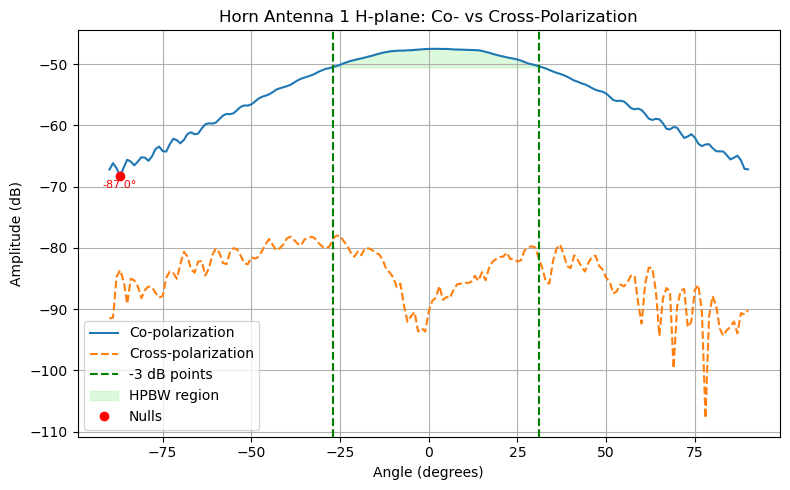

HPBW: 58.00° (from -27.0° to 31.0°)
Nulls found at angles (deg): ['-87.0']
Cross Polarization Suppression (XPS): 30.52 dB
  Co-pol max within HPBW: -47.48 dB
  Cross-pol max within HPBW: -78.00 dB


In [33]:
plot_polarizations(
    'testplots\ex6_h1_hplane_co.mat',
    'testplots\ex6_h1_hplane_x.mat',
    #'testplots\horn1HplaneCO.mat',
    #'testplots\horn1HplaneX.mat',
    title="Horn Antenna 1 H-plane: Co- vs Cross-Polarization",
    prominence=2
)

####    5.6.3 Co- and Cross-polarization in the **E-plane** for **Horn 2** in one diagram


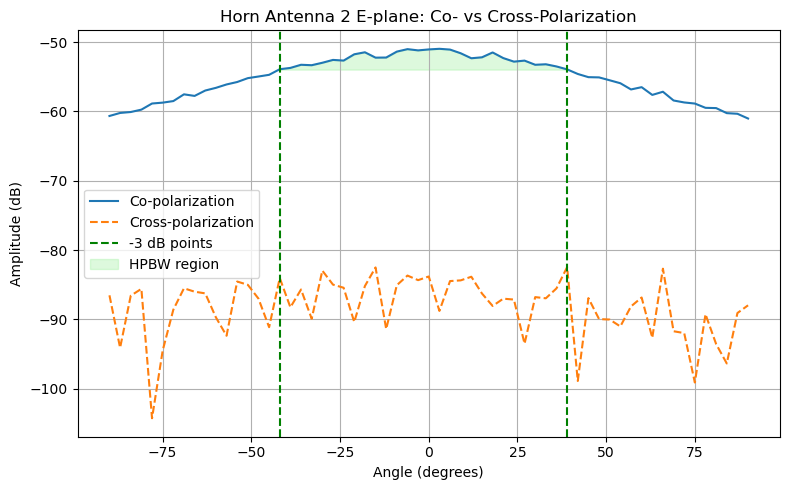

HPBW: 81.00° (from -42.0° to 39.0°)
Nulls found at angles (deg): []
Cross Polarization Suppression (XPS): 31.49 dB
  Co-pol max within HPBW: -50.97 dB
  Cross-pol max within HPBW: -82.46 dB


In [44]:
plot_polarizations(
    #'Microwave_lab_07_07_25/Measurement_Antennas/Uncalibrated/563_HornEplane_Co.mat',
    #'Microwave_lab_07_07_25/Measurement_Antennas/Uncalibrated/563_HornEplane_X.mat',
    #'testplots\ex6_h2_eplane_co.mat',
    #'testplots\ex6_h2_eplane_x.mat',
    #'testplots\Co-Pol-Horn2-E-Plane.mat',
    #'testplots\X-Pol-Horn2-E-Plane-redo.mat',
    'Microwave_lab_07_07_25/Measurement_Antennas/Uncalibrated/564_HornHplane_Co.mat',
    'Microwave_lab_07_07_25/Measurement_Antennas/Uncalibrated/564_HornHplane_X.mat',
    title="Horn Antenna 2 E-plane: Co- vs Cross-Polarization",
    prominence=5
)

#### 5.6.4 Co- and Cross-polarization in the **H-plane** for **Horn 2** in one diagram

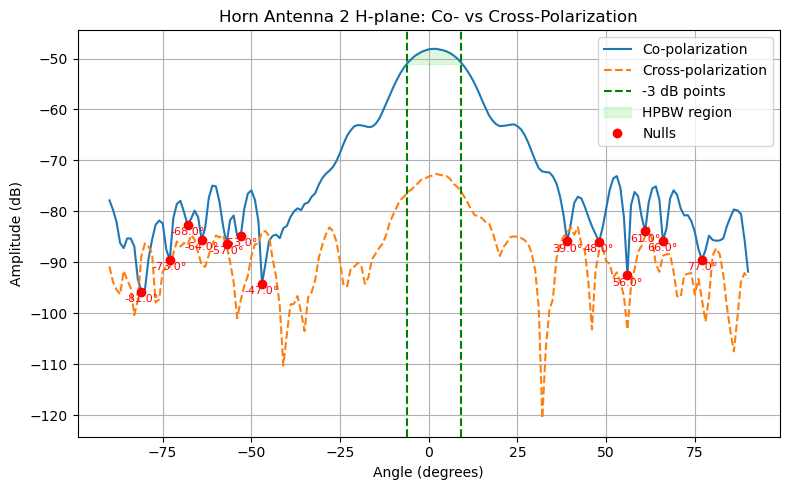

HPBW: 15.00° (from -6.0° to 9.0°)
Nulls found at angles (deg): ['-81.0', '-73.0', '-68.0', '-64.0', '-57.0', '-53.0', '-47.0', '39.0', '48.0', '56.0', '61.0', '66.0', '77.0']
Cross Polarization Suppression (XPS): 24.57 dB
  Co-pol max within HPBW: -48.08 dB
  Cross-pol max within HPBW: -72.65 dB


In [ ]:
plot_polarizations(
    #'Microwave_lab_07_07_25/Measurement_Antennas/Uncalibrated/564_HornHplane_Co.mat',
    #'Microwave_lab_07_07_25/Measurement_Antennas/Uncalibrated/564_HornHplane_X.mat',
    'Microwave_lab_07_07_25/Measurement_Antennas/Uncalibrated/563_HornEplane_Co.mat',
    'Microwave_lab_07_07_25/Measurement_Antennas/Uncalibrated/563_HornEplane_X.mat',
    #'testplots\ex6_h2_hplane_co.mat',
    #'testplots\ex6_h2_hplane_x.mat',
    title="Horn Antenna 2 H-plane: Co- vs Cross-Polarization",
    prominence=2
)

- Compare the shape of diagrams **1** and **4**:
    - <span style="color:red">– Why is there a difference, although the size of the aperture is identical?</span>


FileNotFoundError: [Errno 2] No such file or directory: 'Microwave_lab_07_07_25/Measurement_Antennas/Calibrated/5.6.1 co hplane horn 1.mat'

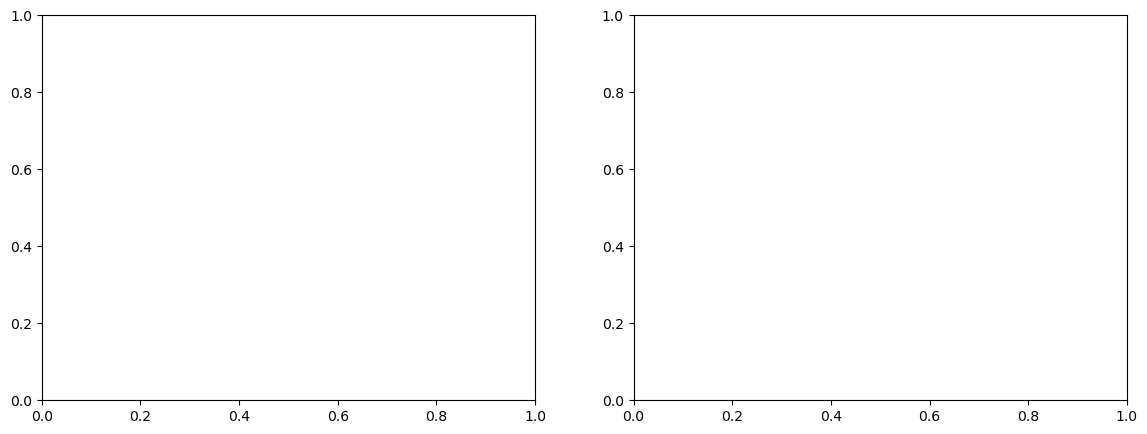

In [28]:
def load_fields(co_path, x_path):
    co_data = loadMatlabData(co_path)['messdummy'][0]
    x_data = loadMatlabData(x_path)['messdummy'][0]
    angles = co_data['angles'].flatten()
    E_co = 20 * np.log10(np.abs(co_data['measured_data'].flatten()))
    E_x = 20 * np.log10(np.abs(x_data['measured_data'].flatten()))
    return angles, E_co, E_x

def plot_comparison_subplots(co_paths, x_paths, titles, prominence=5):
    fig, axs = plt.subplots(1, 2, figsize=(14, 5))

    for i in range(2):
        angles, E_co, E_x = load_fields(co_paths[i], x_paths[i])
        ax = axs[i]

        # Plot Co and X
        ax.plot(angles, E_co, label="Co-pol")
        ax.plot(angles, E_x, '--', label="X-pol")

        # HPBW
        max_E = np.max(E_co)
        threshold = max_E - 3
        hpbw_idx = np.where(E_co >= threshold)[0]
        if len(hpbw_idx) >= 2:
            left = angles[hpbw_idx[0]]
            right = angles[hpbw_idx[-1]]
            ax.axvline(left, linestyle='--', color='green', label='-3 dB points' if i == 0 else "")
            ax.axvline(right, linestyle='--', color='green')
            ax.fill_between(angles, E_co, threshold,
                            where=(angles >= left) & (angles <= right),
                            color='lightgreen', alpha=0.3, label='HPBW' if i == 0 else "")
            # XPS
            in_hpbw = (angles >= left) & (angles <= right)
            G_co = np.max(E_co[in_hpbw])
            G_x = np.max(E_x[in_hpbw])
            xps = G_co - G_x
            print(f"\n {titles[i]}")
            print(f"HPBW: {right - left:.2f}° (from {left:.1f}° to {right:.1f}°)")
            print(f"XPS: {xps:.2f} dB")
        else:
            print(f"\n HPBW could not be determined for {titles[i]}")

        # Nulls (only if found)
        null_idx, _ = find_peaks(-E_co, prominence=prominence)
        if len(null_idx) > 0:
            null_angles = angles[null_idx]
            null_values = E_co[null_idx]
            ax.plot(null_angles, null_values, 'ro', label="Nulls" if i == 0 else "")
            for a, v in zip(null_angles, null_values):
                ax.text(a, v - 3, f"{a:.0f}°", ha='center', fontsize=7, color='red')
            print("Nulls at:", [f"{a:.1f}°" for a in null_angles])
        else:
            print("No nulls found.")

        # Labels and title
        ax.set_title(titles[i])
        ax.set_xlabel("Angle (°)")
        ax.set_ylabel("Amplitude (dB)")
        ax.grid(True)
        ax.legend()

    plt.suptitle("Comparison of Horn Antenna Radiation Patterns: Diagram 1 vs Diagram 4", fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

# === FILE PATHS ===
co_paths = [
    "Microwave_lab_07_07_25/Measurement_Antennas/Calibrated/5.6.1 co hplane horn 1",   # Diagram 1
    "Microwave_lab_07_07_25/Measurement_Antennas/Calibrated/561_HornHplane_Co.mat"    # Diagram 4
]

x_paths = [
    "Microwave_lab_07_07_25/Measurement_Antennas/Calibrated/564_HornHplane_X.mat",    # Diagram 1
    "Microwave_lab_07_07_25/Measurement_Antennas/Calibrated/564_HornHplane_X.mat"     # Diagram 4
]

titles = ["Diagram 1 - Horn E-plane", "Diagram 4 - Horn H-plane"]

# === CALL FUNCTION ===
plot_comparison_subplots(co_paths, x_paths, titles)

<span style="color:red">ASNWER HERE</span>

- Compare the results (**nulls, HPBW, shape**) of diagram **1** with the theoretical calculations from **Exercise 5.4**:
    - Why are there fewer nulls?
    - Why are the nulls not as distinctive?

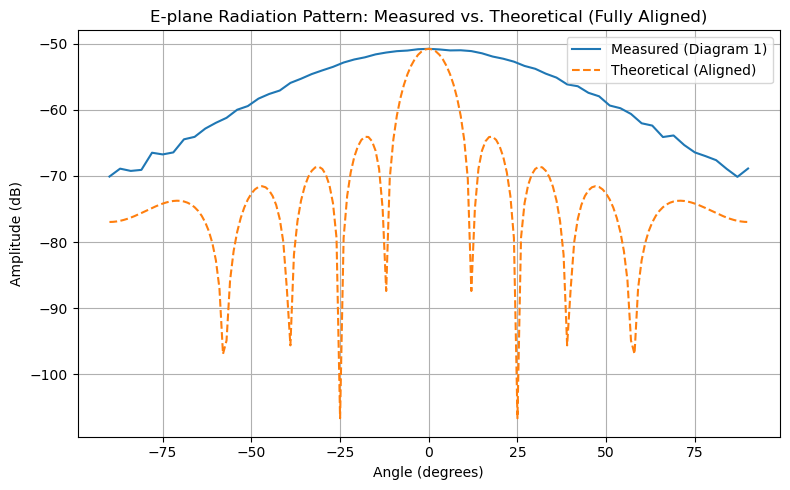

In [ ]:
# --- Load measured data (Diagram 1 – E-plane) ---
data = loadMatlabData("Microwave_lab_07_07_25/Measurement_Antennas/Uncalibrated/561_HornEplane_Co.mat")
mess = data['messdummy'][0]
angles_meas = mess['angles'].flatten()
E_meas = mess['measured_data'].flatten()
E_meas_dB = 20 * np.log10(np.abs(E_meas))

# --- Find measured maximum angle and gain ---
max_idx_meas = np.argmax(E_meas_dB)
main_lobe_angle_meas = angles_meas[max_idx_meas]
max_gain_meas = E_meas_dB[max_idx_meas]

# --- Theoretical pattern (main lobe at 90° initially) ---
c = 3e8
f = 11.85e9
λ = c / f
b = 0.12
beta = 2 * np.pi / λ

theta_deg_theo = np.linspace(0, 180, 181)
theta_rad = np.radians(theta_deg_theo)
B = (b * beta * np.cos(theta_rad)) / 2
B[B == 0] = 1e-12
U_norm = np.abs(np.sin(B) / B)
U_dB = 20 * np.log10(U_norm)

# --- Align main lobe horizontally ---
main_lobe_angle_theo = 90
angular_shift = main_lobe_angle_meas - main_lobe_angle_theo
aligned_theta = theta_deg_theo + angular_shift

# --- Align vertically by matching max gain ---
max_gain_theo = np.max(U_dB)
vertical_shift = max_gain_meas - max_gain_theo
U_dB_aligned = U_dB + vertical_shift

# --- Overlay Plot ---
plt.figure(figsize=(8, 5))
plt.plot(angles_meas, E_meas_dB, label="Measured (Diagram 1)", color='tab:blue')
plt.plot(aligned_theta, U_dB_aligned, label="Theoretical (Aligned)", color='tab:orange', linestyle='--')
plt.title("E-plane Radiation Pattern: Measured vs. Theoretical (Fully Aligned)")
plt.xlabel("Angle (degrees)")
plt.ylabel("Amplitude (dB)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### Exercise 5.7 – Patch Antenna Measurement (Experiment)

- Record the radiation patterns (**Co- and Cross-polarization**) of the **patch antenna** in the **H-plane** for **f = 2 GHz**.

- Print the following (not normalized) diagram:
    - Co- and Cross-polarization in the **H-plane** in one diagram.

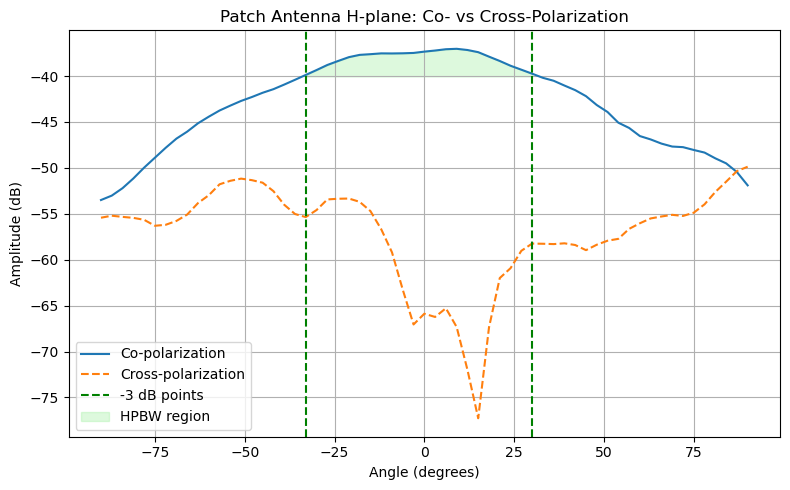

HPBW: 63.00° (from -33.0° to 30.0°)
Nulls found at angles (deg): []
Cross Polarization Suppression (XPS): 16.30 dB
  Co-pol max within HPBW: -37.04 dB
  Cross-pol max within HPBW: -53.34 dB


In [ ]:
plot_polarizations(
    'Microwave_lab_07_07_25/Measurement_Antennas/Uncalibrated/571_Patch1Hplane_Co.mat',
    'Microwave_lab_07_07_25/Measurement_Antennas/Uncalibrated/571_Patch1Hplane_X.mat',
    title="Patch Antenna H-plane: Co- vs Cross-Polarization",
    prominence=2
)

- Compare the dimensions of the patch antenna with the calculated dimensions from **Exercise 5.2**.

The dimensions of the patch antenna were W=46mm and L=50mm. The ones obtained from the calculations were W=59mm and L=48mm.

- Extract the following values from the diagram:
    - **Half Power Beam Width** (Co-polarization)
    - **Cross-polarization suppression**

- Analyze the result:
    - What conclusions can you draw from the shape of the radiation pattern regarding the **current distribution** on the antenna?

### Exercise 5.8 – Patch Array with Phase Shifters (Experiment)

- Record the radiation pattern of the **4×1 patch array** for all **three phase shifter settings** in the **horizontal direction** for **f = 2 GHz**.  
  *(Be careful with the coaxial connectors!)*

- Print all three measurements (**not normalized**) in **one diagram**.


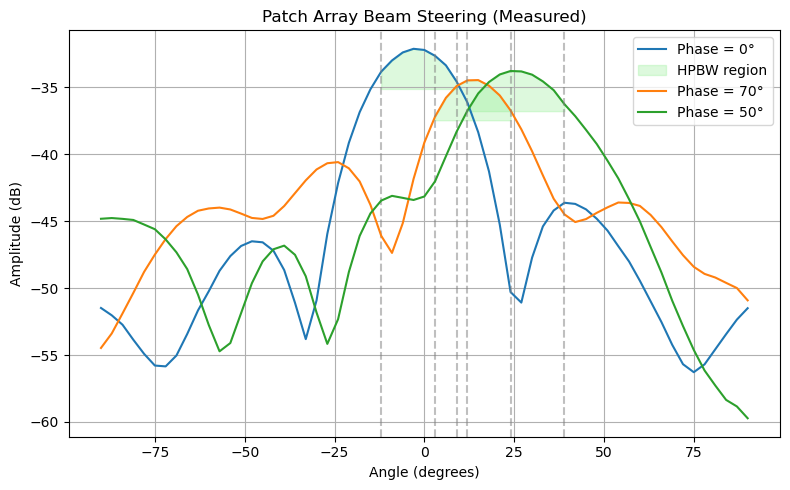

In [ ]:
plot_array_patterns(
    paths=[
        'Microwave_lab_07_07_25/Measurement_Antennas/Uncalibrated/581_Patch4Hplane_0deg_Co.mat',
        "Microwave_lab_07_07_25/Measurement_Antennas/Uncalibrated/581_Patch4Hplane_62deg_Co.mat",
        "Microwave_lab_07_07_25/Measurement_Antennas/Uncalibrated/581_Patch4Hplane_137deg_Co_twisted.mat"
    ],
    labels=["Phase = 0°", "Phase = 70°", "Phase = 50°"],
    title="Patch Array Beam Steering (Measured)"
)

- Determine the **pivoting angles** corresponding to each phase shift.

- Compare the measured results with your calculations from **Exercise 5.3** and explain any differences.

- Analyze the results:
  - How do the three radiation patterns differ in terms of **Half Power Beam Width (HPBW)** and **gain**, and why?

- Additionally:
  - Plot the **radiation pattern without phase shift** alongside the single patch result from **Exercise 5.7** in one diagram.

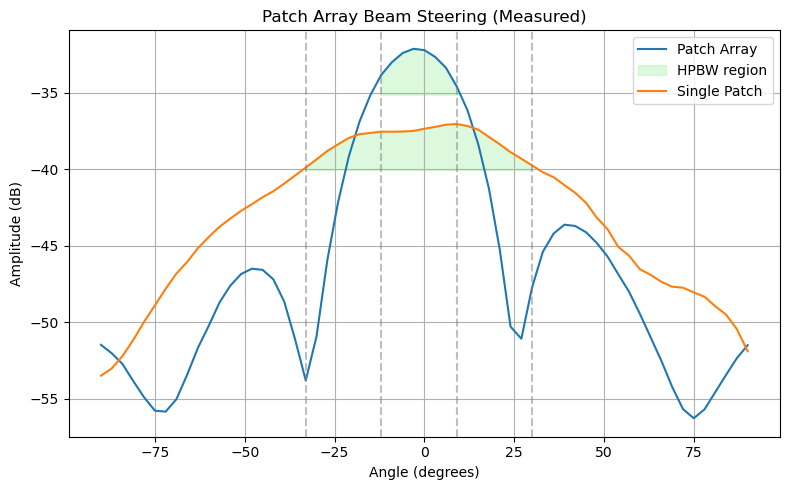

In [ ]:
plot_array_patterns(
    paths=[
        'Microwave_lab_07_07_25/Measurement_Antennas/Uncalibrated/581_Patch4Hplane_0deg_Co.mat',
        "Microwave_lab_07_07_25/Measurement_Antennas/Uncalibrated/571_Patch1Hplane_Co.mat"
    ],
    labels=["Patch Array", "Single Patch"],
    title="Patch Array Beam Steering (Measured)"
)

  - Estimate the **difference in receive power** in the main radiating direction.
  - How large should this difference theoretically be?
  - What could be the reasons for any discrepancy?

- Compare the **HPBW** of the **single patch** with the **patch array**.